In [1]:
import Pkg
using Sunny, GLMakie, StaticArrays, LinearAlgebra

In [2]:
units = Units(:meV, :angstrom);

In [125]:
latvecs = lattice_vectors(7.3177, 7.3177, 17.534, 90, 90, 120)
fe_cryst = Crystal(latvecs, [[1/6, 5/6, 5/6]], 166)

# cryst = Crystal("ammoniojarosite.cif")
# fe_cryst = subcrystal(cryst, "Fe")
moments = [1 => Moment(s=5/2, g=2)]  
sys = System(fe_cryst, moments, :dipole; dims=(3,3,3))

D = [0, 0.218, -0.195]
set_exchange!(sys, 3.3*Matrix(I, 3, 3) + dmvec(D), Bond(1, 2, [0, 0, 0]))
set_exchange!(sys, 0.11, Bond(1, 2, [1, 0, 0]))
set_exchange!(sys, 0.11, Bond(1, 2, [0, 1, 0]))

In [126]:
display(view_crystal(fe_cryst))

GLMakie.Screen(...)

In [127]:
randomize_spins!(sys)
minimize_energy!(sys)
# plot_spins(sys; color=[S[3] for S in sys.dipoles], ndims=2)

Converged in 548 iterations

In [128]:
qs1 = [[0, 0, 0], [1/3, 1/3, 0], [1/2, 0, 0], [0, 0, 0]]
qs2 = [[0, 0, 1], [1/3, 1/3, 1], [1/2, 0, 1], [0, 0, 1]]
qs3 = [[0, 0, -1], [1/3, 1/3, -1], [1/2, 0, -1], [0, 0, -1]]
labels = ["Γ", "K", "M", "Γ"]
path1 = q_space_path(fe_cryst, qs1, 150; labels)
path2 = q_space_path(fe_cryst, qs2, 150; labels)
path3 = q_space_path(fe_cryst, qs3, 150; labels)


kernel = lorentzian(fwhm=0.8)
energies = range(0, 25, 150)

0.0:0.16778523489932887:25.0

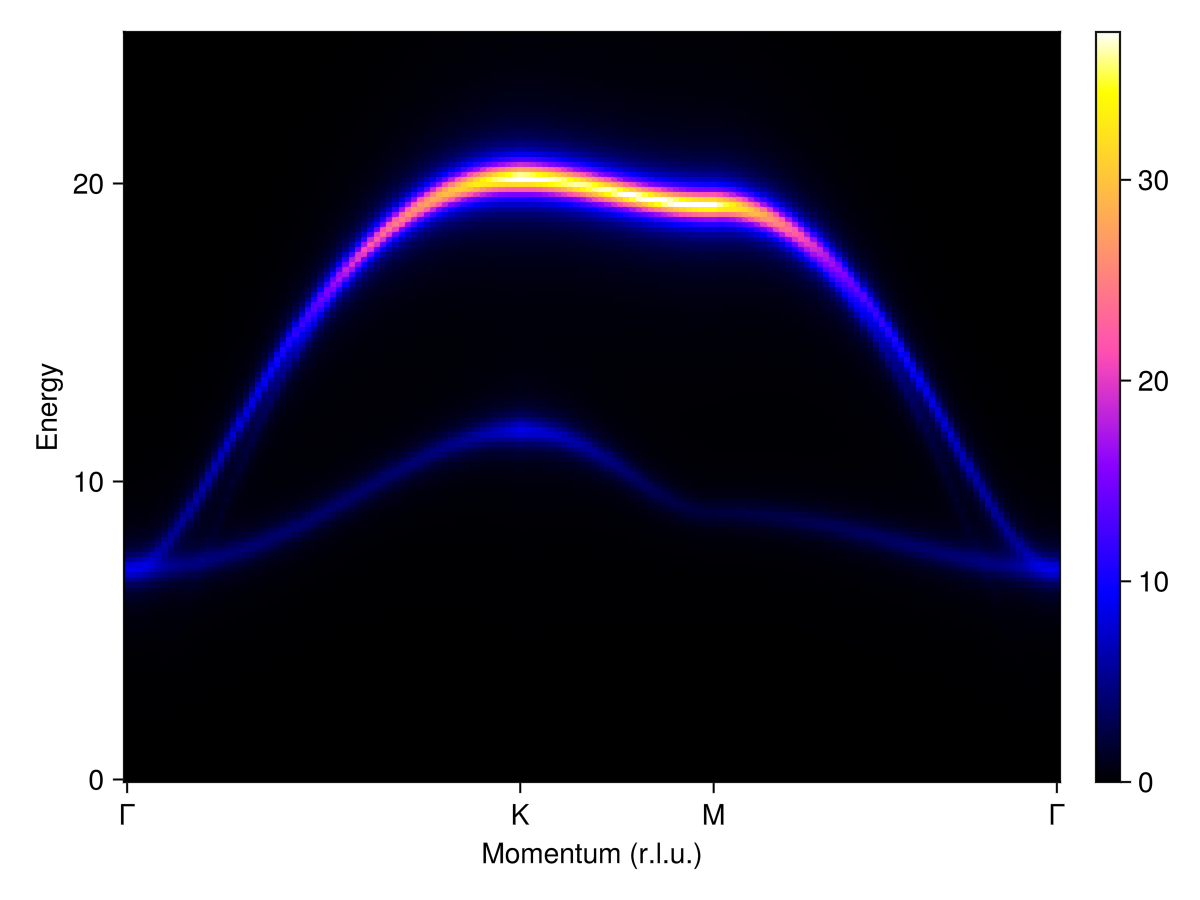

In [131]:
swt = SpinWaveTheory(sys; measure=ssf_perp(sys))
res1 = intensities(swt, path1; energies, kernel)
res2 = intensities(swt, path2; energies, kernel)
res3 = intensities(swt, path3; energies, kernel)
res_data = (res1.data + res2.data + res3.data)/3
res_e = (res1.energies + res2.energies + res3.energies)/3

filepath = joinpath(@__DIR__, "resdata.txt")
filepath2 = joinpath(@__DIR__, "resE.txt")
open(filepath, "w") do f
    for row in eachrow(res_data)
        println(f, join(row, ", "))
    end
end
open(filepath2, "w") do f
    for row in eachrow(res_e)
        println(f, join(row, ", "))
    end
end

plot_intensities(res3)

In [67]:
sys_inhom = to_inhomogeneous(repeat_periodically(sys, (20, 20, 3)))

System [Dipole mode]
Supercell (20×20×3)×9
Energy per site -24.19


In [68]:
for (site1, site2, offset) in symmetry_equivalent_bonds(sys_inhom, Bond(1, 1, [1, 0, 0]))
    noise = randn(sys_inhom.rng)/3
    set_exchange_at!(sys_inhom, 1.0 + noise, site1, site2; offset)
end

minimize_energy!(sys_inhom, maxiters=20000)
display(plot_spins(sys_inhom; color=[S[3] for S in sys_inhom.dipoles], ndims=2))

LoadError: System not two-dimensional in (a₁, a₂)

In [30]:
swt = SpinWaveTheoryKPM(sys_inhom; measure=ssf_perp(sys_inhom), tol=0.05)
res = intensities(swt, path; energies, kernel)
plot_intensities(res, colorrange = (0, 20))

LoadError: Not an energy-minimum; wavevector q = [0.005291005291005291, 0.005291005291005291, 0.0] unstable.

In [22]:
radii = range(0, 3, 50) # (1/Å)
res = powder_average(cryst, radii, 50) do qs
    intensities(swt, qs; energies, kernel)
end
plot_intensities(res; units, saturation=1.0, title="Powder Average")

LoadError: Not an energy-minimum; wavevector q = [0.005110087736541705, 0.022146630384407437, 0.15611015718986865] unstable.